In [1]:
from llama_index.core import SimpleDirectoryReader
from llama_index.core.node_parser import MarkdownNodeParser

# 1. LOAD: Read the Markdown files you downloaded from LlamaIndex Cloud
# This looks into your 'data' folder and pulls in all .md files.
reader = SimpleDirectoryReader(input_dir="./data/markdown")
documents = reader.load_data()

# 2. DIVIDE: Use the Markdown headers to split the text logically
# Instead of cutting by character count, it cuts when it sees a new ## or ###
parser = MarkdownNodeParser()
nodes = parser.get_nodes_from_documents(documents)

# 3. VERIFY: Let's see what the "Sections" actually look like
print(f"--- Division Complete ---")
print(f"Total logical sections found: {len(nodes)}\n")

# Peek at the first 3 nodes to see the 'Context' (the headers)
for i, node in enumerate(nodes[:3]):
    # Get the header title from metadata
    header = node.metadata.get("header_path", "Main Title")
    print(f"SECTION {i}: {header}")
    print(f"TEXT PREVIEW: {node.text[:100]}...")
    print("-" * 30)

--- Division Complete ---
Total logical sections found: 165

SECTION 0: /
TEXT PREVIEW: An illustration shows a person lying in bed, covering their face with their hands, with a scribbled ...
------------------------------
SECTION 1: /
TEXT PREVIEW: ## Is it stress or anxiety?

<table>
  <tbody>
    <tr>
        <td>Stress</td>
        <td>Both Str...
------------------------------
SECTION 2: /
TEXT PREVIEW: ## Ways to Cope
* Keep a journal.
* Download an app with relaxation exercises.
* Exercise and eat he...
------------------------------


* Now that we have our Nodes (sections like "Symptoms" or "Diagnosis"), we face a classic RAG problem: Context Loss. If the AI finds a node that says "Treatment involves CBT and SSRIs," but it doesn't know that node came from the Social Anxiety brochure, it might accidentally use that answer for PTSD.

* Contextual Enrichment solves this by using an LLM to "stamp" each node with its identity. We are basically "gluing" the metadata directly into the text so that when we build our Knowledge Graph in the next phase, the relationships (Triplets) are 100% accurate.

In [2]:
import os 

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

* we're gonna use different LLMs in experimental results and we're gonna benchmark and compare the results based on accuracy..

### Initialize the LLM

In [3]:
from llama_index.llms.openai import OpenAI

# 1. Initialize the "Contextualizer" LLM
# We use a fast, cost-effective model for this (like GPT-4o-mini)
llm = OpenAI(model="gpt-4o-mini", 
             api_key=api_key)

In [ ]:
# 2. Define the Enrichment Function
def enrich_nodes_with_context(nodes):
    enriched_nodes = []
    
    print(f"Starting enrichment for {len(nodes)} nodes...")
    
    for node in nodes:
        # Get the filename or title from metadata to help the LLM
        source_doc = node.metadata.get("file_name", "Unknown Document")
        
        # PROMPT: We ask the LLM to situate this specific chunk
        prompt = f"""
        Below is a section from a mental health brochure titled '{source_doc}'. 
        Please provide a 1-sentence context that describes what disorder and what sub-topic 
        (e.g., Symptoms, Treatment, Causes) this text belongs to. 
        
        TEXT: {node.text[:500]}...
        
        Output only the context sentence and nothing else.
        """
        
        # Generate the tag
        context_tag = llm.complete(prompt).text.strip()
        
        # PREPEND: We add the context to the actual text of the node
        # This is the "magic" that makes GraphRAG much safer.
        node.text = f"[CONTEXT: {context_tag}]\n\n" + node.text
        
        enriched_nodes.append(node)
        print(f"Enriched: {context_tag[:50]}...")
        
    return enriched_nodes

# 3. EXECUTE
enriched_nodes = enrich_nodes_with_context(nodes)

Starting enrichment for 165 nodes...
Enriched: This text belongs to the topic of Symptoms related...
Enriched: This text belongs to the topic of Symptoms related...
Enriched: This text belongs to the sub-topic "Ways to Cope" ...
Enriched: This text belongs to the topic of Treatment for st...
Enriched: This text belongs to the sub-topic of Symptoms rel...
Enriched: This text belongs to the disorder "Seasonal Affect...
Enriched: This text belongs to the disorder Seasonal Affecti...
Enriched: This text belongs to the disorder Seasonal Affecti...
Enriched: This text belongs to the disorder Seasonal Affecti...
Enriched: This text belongs to the disorder Seasonal Affecti...
Enriched: This text belongs to the disorder Seasonal Affecti...
Enriched: This text discusses the treatment of Seasonal Affe...
Enriched: This text discusses the treatment of Seasonal Affe...
Enriched: This text belongs to the disorder Seasonal Affecti...
Enriched: This text discusses the treatment of Seasonal Affe...
Enr

* in the response we want to display the source of the information (source citation)

## Save Cell

In [14]:
import pickle
import os

print("💾 Creating Checkpoints...")
# Create a folder to hold your saved states
os.makedirs("./checkpoints", exist_ok=True)

# 1. Save your Enriched Nodes (So you never have to run enrichment again)
with open("./checkpoints/enriched_nodes.pkl", "wb") as f:
    pickle.dump(enriched_nodes, f)
    print("✅ Enriched Nodes saved to disk!")


💾 Creating Checkpoints...
✅ Enriched Nodes saved to disk!


## Load Cell

In [4]:
import pickle
import os

print("🔄 Loading Checkpoints from disk...")

# 1. Load the Enriched Nodes
if os.path.exists("./checkpoints/enriched_nodes.pkl"):
    with open("./checkpoints/enriched_nodes.pkl", "rb") as f:
        enriched_nodes = pickle.load(f)
    print(f"✅ Loaded {len(enriched_nodes)} enriched nodes!")
else:
    print("⚠️ No enriched nodes checkpoint found.")

🔄 Loading Checkpoints from disk...
✅ Loaded 165 enriched nodes!


# Graph construction + Triplets extraction

In [47]:
# ============================================================
# CANONICALIZATION UTILITIES — V2
# Fixes: plural/singular (Issue 4), type conflict (Issue 1)
# ============================================================

import re

ABBREVIATION_MAP = {
    "CBT":   "COGNITIVE BEHAVIORAL THERAPY",
    "DBT":   "DIALECTICAL BEHAVIOR THERAPY",
    "ACT":   "ACCEPTANCE AND COMMITMENT THERAPY",
    "EMDR":  "EYE MOVEMENT DESENSITIZATION AND REPROCESSING",
    "ECT":   "ELECTROCONVULSIVE THERAPY",
    "TMS":   "TRANSCRANIAL MAGNETIC STIMULATION",
    "SSRI":  "SELECTIVE SEROTONIN REUPTAKE INHIBITOR",
    "SNRI":  "SEROTONIN NOREPINEPHRINE REUPTAKE INHIBITOR",
    "TCA":   "TRICYCLIC ANTIDEPRESSANT",
    "MAOI":  "MONOAMINE OXIDASE INHIBITOR",
    "MDD":   "MAJOR DEPRESSIVE DISORDER",
    "GAD":   "GENERALIZED ANXIETY DISORDER",
    "PTSD":  "POST TRAUMATIC STRESS DISORDER",
    "OCD":   "OBSESSIVE COMPULSIVE DISORDER",
    "BPD":   "BORDERLINE PERSONALITY DISORDER",
    "ADHD":  "ATTENTION DEFICIT HYPERACTIVITY DISORDER",
    "SAD":   "SEASONAL AFFECTIVE DISORDER",
    "BDD":   "BODY DYSMORPHIC DISORDER",
    "ASD":   "AUTISM SPECTRUM DISORDER",
}

# FIX ISSUE 4: Simple singularization rules
# Handles the most common English plural patterns
def singularize(name: str) -> str:
    if name.endswith("IES") and len(name) > 4:
        return name[:-3] + "Y"           # THERAPIES → THERAPY
    if name.endswith("SSES"):
        return name[:-2]                  # OBSESSIONS → already singular; STRESSES → STRESS
    if name.endswith("S") and not name.endswith("SS") and len(name) > 4:
        # Don't singularize: PTSD, STRESS, AIDS, etc.
        exceptions = {"STRESS", "AIDS", "CRISIS", "DIAGNOSIS", "PSYCHOSIS",
                      "NEUROSIS", "PROGNOSIS", "THESIS", "BASIS"}
        if name not in exceptions:
            return name[:-1]              # SYMPTOMS → SYMPTOM, MEDICATIONS → MEDICATION
    return name

def canonicalize(name: str) -> str:
    name = name.strip().upper()
    name = name.replace("-", " ").replace("_", " ")
    name = " ".join(name.split())
    name = ABBREVIATION_MAP.get(name, name)
    name = singularize(name)
    return name

# ============================================================
# FIX ISSUE 1: Type priority resolver
# When the same entity appears with conflicting types,
# this defines which type wins.
# CONDITION > MEDICATION > TREATMENT > SYMPTOM > DEMOGRAPHIC > SAFETY_RESOURCE
# ============================================================
TYPE_PRIORITY = {
    "CONDITION":       6,
    "MEDICATION":      5,
    "TREATMENT":       4,
    "SYMPTOM":         3,
    "DEMOGRAPHIC":     2,
    "SAFETY_RESOURCE": 1,
}

def resolve_type(existing_type: str, new_type: str) -> str:
    """Return whichever type has higher priority."""
    return existing_type if TYPE_PRIORITY.get(existing_type, 0) >= TYPE_PRIORITY.get(new_type, 0) else new_type

# ============================================================
# FIX ISSUE 3: Garbage entity detector
# Rejects descriptive phrases masquerading as entities.
# ============================================================
GARBAGE_FRAGMENTS = {
    "COMBINATION", "VARIOUS", "MULTIPLE", "SEVERAL",
    "LIFELONG", "ONGOING", "CONTINUED", "ADDITIONAL",
    "APPROACH", "APPROACHES", "OPTION", "OPTIONS",
    "STRATEGY", "STRATEGIES", "PROGRAM", "PROGRAMS",
    "INTERVENTION", "INTERVENTIONS", "MANAGEMENT",
    "SUPPORT", "SERVICES", "CARE", "HELP",
}

_STOP_WORDS = {"OF", "AND", "OR", "THE", "A", "AN", "WITH", "FOR", "IN", "TO"}

def is_garbage_entity(name: str) -> bool:
    """
    Returns True if the entity is too generic to be a real medical entity.
    Strips stop words first, then checks if remaining words are all garbage.
    """
    words = set(name.upper().split()) - _STOP_WORDS  # ← strip "OF", "AND", etc.
    if not words:
        return True
    # All remaining words are garbage fragments
    if words.issubset(GARBAGE_FRAGMENTS):
        return True
    # Short phrase (1-2 meaningful words) where any word is a garbage fragment
    if len(words) <= 2 and words & GARBAGE_FRAGMENTS:
        return True
    return False

# ============================================================
# FIX ISSUE 2: Semantic relation rules
# Defines which (subject_type, relation) pairs are valid.
# Prevents CBT from having symptoms, etc.
# ============================================================
VALID_SUBJECT_RELATIONS = {
    # (SUBJECT_TYPE, RELATION) → allowed
    ("CONDITION",       "HAS_SYMPTOM"),
    ("CONDITION",       "TREATED_BY"),
    ("CONDITION",       "SUITABLE_FOR"),
    ("CONDITION",       "CONTRAINDICATED_FOR"),
    ("CONDITION",       "URGENT_ACTION"),
    ("MEDICATION",      "PRESCRIBES"),
    ("MEDICATION",      "SUITABLE_FOR"),
    ("MEDICATION",      "CONTRAINDICATED_FOR"),
    ("TREATMENT",       "SUITABLE_FOR"),
    ("TREATMENT",       "CONTRAINDICATED_FOR"),
    ("DEMOGRAPHIC",     "SUITABLE_FOR"),
    ("DEMOGRAPHIC",     "CONTRAINDICATED_FOR"),
    ("SAFETY_RESOURCE", "SUITABLE_FOR"),
    ("SAFETY_RESOURCE", "URGENT_ACTION"),
    ("SYMPTOM",         "URGENT_ACTION"),
}

def is_valid_relation(subj_type: str, relation: str) -> bool:
    return (subj_type, relation) in VALID_SUBJECT_RELATIONS

# Smoke tests
assert canonicalize("MOOD STABILIZERS") == "MOOD STABILIZER"
assert canonicalize("SYMPTOMS")         == "SYMPTOM"
assert canonicalize("THERAPIES")        == "THERAPY"
assert is_garbage_entity("COMBINATION OF TREATMENTS") == True   # "OF" stripped → {COMBINATION, TREATMENTS} ⊆ garbage
assert is_garbage_entity("LIFELONG TREATMENT")        == True   # {LIFELONG, TREATMENT} ⊆ garbage
assert is_garbage_entity("COGNITIVE BEHAVIORAL THERAPY") == False
assert is_garbage_entity("LITHIUM")                   == False
assert is_garbage_entity("CRISIS HOTLINE")            == False
assert is_valid_relation("TREATMENT", "HAS_SYMPTOM")  == False  # Issue 2
assert is_valid_relation("CONDITION",  "HAS_SYMPTOM")  == True

print("✅ All canonicalization and validation utilities loaded and tested.")

✅ All canonicalization and validation utilities loaded and tested.


In [64]:
# ============================================================
# CELL 14 — GRAPH EXTRACTION V4
# Adds: entity descriptions, source tracking, relation
# descriptions, relation strength, and pronoun resolution.
# ============================================================

import re
import json
from llama_index.core.llms import ChatMessage
from llama_index.core import PropertyGraphIndex
from llama_index.core.graph_stores.types import EntityNode, Relation

print("--- GRAPH BUILDER V4 (Microsoft GraphRAG-style) ---")

ALLOWED_TYPES = {
    "CONDITION", "SYMPTOM", "TREATMENT",
    "MEDICATION", "SAFETY_RESOURCE", "DEMOGRAPHIC"
}
ALLOWED_RELATIONS = {
    "HAS_SYMPTOM", "TREATED_BY", "PRESCRIBES",
    "SUITABLE_FOR", "CONTRAINDICATED_FOR", "URGENT_ACTION"
}

# ============================================================
# UPGRADED PROMPT
# Now asks for: descriptions, source_id, relation descriptions,
# relation strength, and explicit pronoun resolution.
# Output is JSON for reliable parsing (no regex fragility).
# ============================================================
extraction_prompt = """
You are a medical knowledge graph extractor for mental health literature.

TASK: Extract entities and relationships from the given text.

STEP 1 — Resolve all pronouns and ambiguous references first.
Replace "it", "they", "this condition", "the disorder", "the medication" etc.
with their actual names based on context. Work with the resolved text.

STEP 2 — Extract entities.
For each entity found, produce:
  - id: sequential string like "n0", "n1", "n2" ...
  - name: specific medical term, UPPERCASE, no generic phrases
  - type: one of [CONDITION, SYMPTOM, TREATMENT, MEDICATION, SAFETY_RESOURCE, DEMOGRAPHIC]
  - description: 1-2 sentences describing what this entity is in the context of mental health

STEP 3 — Extract relationships between the entities from Step 2.
For each relationship:
  - source: id of source entity
  - target: id of target entity
  - relation: one of [HAS_SYMPTOM, TREATED_BY, PRESCRIBES, SUITABLE_FOR, CONTRAINDICATED_FOR, URGENT_ACTION]
  - description: one sentence explaining why these two entities are related
  - strength: integer 1-10 (10 = very strong, clinically certain; 1 = weak, mentioned in passing)

RULES:
- Entity names must be specific (LITHIUM not MEDICATION, FATIGUE not SYMPTOM)
- TREATMENT and MEDICATION can NEVER be source of HAS_SYMPTOM
- Only use allowed types and relations
- Skip generic phrases like "combination of treatments", "various approaches"
- If nothing meaningful to extract, return empty arrays

OUTPUT: Valid JSON only. No markdown, no explanation, no extra text.

{
  "entities": [
    {"id": "n0", "name": "DEPRESSION", "type": "CONDITION", "description": "..."},
    {"id": "n1", "name": "FATIGUE", "type": "SYMPTOM", "description": "..."}
  ],
  "relations": [
    {"source": "n0", "target": "n1", "relation": "HAS_SYMPTOM", "description": "...", "strength": 8}
  ]
}
"""

# ============================================================
# STORAGE
# custom_entities   : canonical name → EntityNode
# entity_id_to_node : UUID          → EntityNode
# entity_descriptions: canonical name → best description seen so far
# entity_sources    : canonical name → set of chunk_ids it was seen in
# relation_metadata : (subj, rel, obj) → {description, strength, sources}
# ============================================================
custom_entities    = {}
entity_id_to_node  = {}
entity_descriptions = {}   # ← NEW: stores rich descriptions
entity_sources     = {}    # ← NEW: tracks which chunks each entity appeared in
custom_relations   = []
relation_metadata  = {}    # ← NEW: description + strength per relation
seen_relations     = set()

skipped_chunks    = 0
skipped_triplets  = 0
type_conflicts    = 0
garbage_rejected  = 0
semantic_rejected = 0
json_parse_errors = 0

# ============================================================
# PROCESS CHUNKS
# ============================================================
for i, node in enumerate(enriched_nodes[:]):
    chunk_id = node.node_id  # LlamaIndex node UUID — this IS our source ID

    print(f"Processing chunk {i+1}/{len(enriched_nodes)} [chunk_id: {chunk_id[:8]}...]")

    try:
        system_msg = ChatMessage(role="system", content=extraction_prompt)
        user_msg   = ChatMessage(role="user",
                                 content=f"Extract from this text:\n\n{node.text}")
        response   = llm.chat([system_msg, user_msg]).message.content.strip()

        # Strip markdown fences if LLM wraps response in ```json
        response = re.sub(r"^```(?:json)?\s*", "", response)
        response = re.sub(r"\s*```$", "", response)

        if not response:
            skipped_chunks += 1
            continue

        # --------------------------------------------------------
        # Parse JSON
        # --------------------------------------------------------
        try:
            extracted = json.loads(response)
        except json.JSONDecodeError as e:
            json_parse_errors += 1
            print(f"  ⚠️ JSON parse error in chunk {i+1}: {e}")
            continue

        raw_entities  = extracted.get("entities", [])
        raw_relations = extracted.get("relations", [])

        # --------------------------------------------------------
        # Build a local id → canonical_name map for this chunk
        # (e.g. "n0" → "DEPRESSION") so we can resolve relation
        # source/target ids to canonical names
        # --------------------------------------------------------
        local_id_map = {}  # local_id (n0, n1) → canonical name

        for ent in raw_entities:
            raw_name  = ent.get("name", "").strip()
            raw_type  = ent.get("type", "").strip().upper()
            local_id  = ent.get("id", "").strip()
            desc      = ent.get("description", "").strip()

            if not raw_name or not raw_type or not local_id:
                continue

            canon = canonicalize(raw_name)
            local_id_map[local_id] = canon

            # Schema validation
            if raw_type not in ALLOWED_TYPES:
                skipped_triplets += 1
                continue

            # Garbage check
            if is_garbage_entity(canon):
                garbage_rejected += 1
                continue

            # Forbidden placeholder names
            forbidden = ALLOWED_TYPES | ALLOWED_RELATIONS | {"SUBJECT", "OBJECT", "ENTITY"}
            if canon in forbidden:
                skipped_triplets += 1
                continue

            # ── Store or update entity ──────────────────────────
            if canon not in custom_entities:
                new_node = EntityNode(
                    name=canon,
                    label=raw_type,
                    properties={"description": desc, "sources": [chunk_id]}
                )
                custom_entities[canon]          = new_node
                entity_id_to_node[new_node.id]  = new_node
                entity_descriptions[canon]      = desc
                entity_sources[canon]           = {chunk_id}

            else:
                existing = custom_entities[canon]

                # Resolve type conflict (CONDITION > MEDICATION > TREATMENT > SYMPTOM)
                resolved = resolve_type(existing.label, raw_type)
                if resolved != existing.label:
                    type_conflicts += 1
                    existing.label = resolved

                # Merge descriptions: keep the longer, more informative one
                if len(desc) > len(entity_descriptions.get(canon, "")):
                    entity_descriptions[canon] = desc
                    existing.properties["description"] = desc

                # Add this chunk as another source
                entity_sources.setdefault(canon, set()).add(chunk_id)
                existing.properties["sources"] = list(entity_sources[canon])

        # --------------------------------------------------------
        # Process relations
        # --------------------------------------------------------
        for rel_data in raw_relations:
            src_local  = rel_data.get("source", "")
            tgt_local  = rel_data.get("target", "")
            rel_label  = rel_data.get("relation", "").strip().upper()
            rel_desc   = rel_data.get("description", "").strip()
            rel_strength = int(rel_data.get("strength", 5))

            # Resolve local ids to canonical names
            subj = local_id_map.get(src_local)
            obj  = local_id_map.get(tgt_local)

            if not subj or not obj:
                skipped_triplets += 1
                continue

            # Must exist in our entity store (passed all filters above)
            if subj not in custom_entities or obj not in custom_entities:
                skipped_triplets += 1
                continue

            if rel_label not in ALLOWED_RELATIONS:
                skipped_triplets += 1
                continue

            # Semantic validation
            subj_type = custom_entities[subj].label
            if not is_valid_relation(subj_type, rel_label):
                semantic_rejected += 1
                continue

            # Deduplicate
            rel_key = (subj, rel_label, obj)
            if rel_key in seen_relations:
                # Even if duplicate, update strength if this one is stronger
                if rel_key in relation_metadata:
                    if rel_strength > relation_metadata[rel_key]["strength"]:
                        relation_metadata[rel_key]["strength"] = rel_strength
                    relation_metadata[rel_key]["sources"].add(chunk_id)
                continue

            seen_relations.add(rel_key)

            relation = Relation(
                source_id=custom_entities[subj].id,
                target_id=custom_entities[obj].id,
                label=rel_label,
            )
            custom_relations.append(relation)

            # Store rich metadata for this relation
            relation_metadata[rel_key] = {
                "description": rel_desc,
                "strength":    rel_strength,
                "sources":     {chunk_id},   # which chunks support this fact
            }

    except Exception as e:
        print(f"  ⚠️ Chunk {i+1} failed: {e}")
        skipped_chunks += 1
        continue

print(f"\n✅ Extraction complete!")
print(f"   Unique entities      : {len(custom_entities)}")
print(f"   Unique relations     : {len(custom_relations)}")
print(f"   Skipped chunks       : {skipped_chunks}")
print(f"   JSON parse errors    : {json_parse_errors}")
print(f"   Skipped (schema)     : {skipped_triplets}")
print(f"   Skipped (garbage)    : {garbage_rejected}")
print(f"   Skipped (semantic)   : {semantic_rejected}")
print(f"   Type conflicts fixed : {type_conflicts}")

# Index
print("\nIndexing into Knowledge Graph...")
index = PropertyGraphIndex(nodes=[])
for entity in custom_entities.values():
    index.property_graph_store.upsert_nodes([entity])
index.property_graph_store.upsert_relations(custom_relations)

all_triplets = index.property_graph_store.get_triplets()
print(f"\n✅ Total triplets indexed: {len(all_triplets)}")
for t in all_triplets[:10]:
    print(f"  ({t[0].name} [{t[0].label}]) -[{t[1].label}]-> ({t[2].name} [{t[2].label}])")

--- GRAPH BUILDER V4 (Microsoft GraphRAG-style) ---
Processing chunk 1/165 [chunk_id: bcac793c...]
Processing chunk 2/165 [chunk_id: b2bb985b...]
Processing chunk 3/165 [chunk_id: d029e807...]
Processing chunk 4/165 [chunk_id: 8a6ebfa9...]
Processing chunk 5/165 [chunk_id: 6567cd76...]
Processing chunk 6/165 [chunk_id: a8a147de...]
Processing chunk 7/165 [chunk_id: 690cff8a...]
Processing chunk 8/165 [chunk_id: 5cc6dd4b...]
Processing chunk 9/165 [chunk_id: a853974e...]
Processing chunk 10/165 [chunk_id: b501f5c1...]
Processing chunk 11/165 [chunk_id: f3c664e0...]
Processing chunk 12/165 [chunk_id: cc23bfad...]
Processing chunk 13/165 [chunk_id: d869a168...]
Processing chunk 14/165 [chunk_id: c82aa609...]
Processing chunk 15/165 [chunk_id: 7652deb5...]
Processing chunk 16/165 [chunk_id: 61aae347...]
Processing chunk 17/165 [chunk_id: 8424287c...]
Processing chunk 18/165 [chunk_id: 8dd364f9...]
Processing chunk 19/165 [chunk_id: 61d03205...]
Processing chunk 20/165 [chunk_id: 78d97005..

In [69]:
custom_entities

{'ANXIETY': EntityNode(label='CONDITION', embedding=None, properties={'description': 'Anxiety is an internal reaction to stress characterized by persistent feelings of apprehension or dread that interfere with daily life.', 'sources': ['1d166394-befa-4021-b78a-484ea3a7f680', 'b2bb985b-0f84-4f89-b143-46965d0629a0', 'bbd84ab4-daac-483a-8016-8b2fcc74e7b8', 'bcac793c-7c09-49e2-9482-a527b4b7e511', '5dd2bfdb-e03b-468b-a8ff-04dd10c028d7', '98558727-065a-4381-8fab-c8058b28e8bd', 'd995d39d-f4c1-41e3-9882-0a38445b238e', '27424ecb-1fc7-4a96-a611-771684f23828', '690cff8a-920a-42c7-bf36-9d6140ad7f7b', '0ffb4d22-f4ac-402f-9229-d2ce2a6c84c0', 'e97301d6-be01-45c5-be0b-78643013b498', '0238e9f7-0e14-4130-b2c2-7102048ba863', 'a002efef-cc6f-457e-b0b9-69943719ef5b', 'd6e0a2cd-1020-48c0-80db-53111a7d2601', '18409b07-323c-466c-948f-124c12ad323b', '9ba62a64-c742-4cc7-a568-231df0d2977c', '2d268a23-c0ed-414b-96b6-0b2eaae012ad']}, name='ANXIETY'),
 'STRESS': EntityNode(label='CONDITION', embedding=None, properti

In [70]:
custom_relations

[Relation(label='HAS_SYMPTOM', source_id='ANXIETY', target_id='STRESS', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='STRESS', target_id='EXCESSIVE WORRY', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='STRESS', target_id='UNEASINESS', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='STRESS', target_id='HEADACHE', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='STRESS', target_id='HIGH BLOOD PRESSURE', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='STRESS', target_id='LOSS OF SLEEP', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='ANXIETY', target_id='EXCESSIVE WORRY', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='ANXIETY', target_id='UNEASINESS', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='ANXIETY', target_id='LOSS OF SLEEP', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='SEASONAL AFFECTIVE DISORDER', target_id='MOOD CHANGE', properties={}),
 Relation(label='HAS_SYMPTOM', source_id='WIN

## Save relations and entities cell

In [65]:
import pickle, os
os.makedirs("./checkpoints", exist_ok=True)

with open("./checkpoints/custom_entities.pkl", "wb") as f:
    pickle.dump(custom_entities, f)
    print("✅ custom_entities saved")

with open("./checkpoints/entity_id_to_node.pkl", "wb") as f:
    pickle.dump(entity_id_to_node, f)
    print("✅ entity_id_to_node saved")

with open("./checkpoints/custom_relations.pkl", "wb") as f:
    pickle.dump(custom_relations, f)
    print("✅ custom_relations saved")

# NEW: save rich metadata
with open("./checkpoints/entity_descriptions.pkl", "wb") as f:
    pickle.dump(entity_descriptions, f)
    print("✅ entity_descriptions saved")

with open("./checkpoints/entity_sources.pkl", "wb") as f:
    pickle.dump(entity_sources, f)
    print("✅ entity_sources saved")

with open("./checkpoints/relation_metadata.pkl", "wb") as f:
    # Convert sets to lists for pickle compatibility
    serializable = {
        k: {**v, "sources": list(v["sources"])}
        for k, v in relation_metadata.items()
    }
    pickle.dump(serializable, f)
    print("✅ relation_metadata saved")

print(f"\n📊 {len(custom_entities)} entities, {len(custom_relations)} relations")

✅ custom_entities saved
✅ entity_id_to_node saved
✅ custom_relations saved
✅ entity_descriptions saved
✅ entity_sources saved
✅ relation_metadata saved

📊 309 entities, 405 relations


## Load cell

In [ ]:
import pickle, os

print("🔄 Loading checkpoints...")

for fname, varname, default in [
    ("custom_entities.pkl",    "custom_entities",    {}),
    ("entity_id_to_node.pkl",  "entity_id_to_node",  {}),
    ("custom_relations.pkl",   "custom_relations",   []),
    ("entity_descriptions.pkl","entity_descriptions",{}),
    ("entity_sources.pkl",     "entity_sources",     {}),
    ("relation_metadata.pkl",  "relation_metadata",  {}),
]:
    path = f"./checkpoints/{fname}"
    if os.path.exists(path):
        with open(path, "rb") as f:
            globals()[varname] = pickle.load(f)
        print(f"✅ Loaded {varname}")
    else:
        globals()[varname] = default
        print(f"⚠️  {fname} not found — using empty default")

# Rebuild entity_id_to_node if missing (backward compat)
if not entity_id_to_node and custom_entities:
    entity_id_to_node = {node.id: node for node in custom_entities.values()}
    print(f"✅ Rebuilt entity_id_to_node ({len(entity_id_to_node)} entries)")

🔄 Loading checkpoints...
✅ Loaded 523 entities
✅ Loaded entity_id_to_node (523 entries)
✅ Loaded 676 relations


In [72]:
from llama_index.core.graph_stores import SimplePropertyGraphStore
from llama_index.core import PropertyGraphIndex

print("--- CLINICAL FACTS IN THE GRAPH ---")

# FIX BUG 3: The original code did custom_entities[rel.source_id].
# custom_entities is keyed by canonical NAME, but rel.source_id is a UUID.
# That lookup either crashes or silently returns wrong data.
# entity_id_to_node is keyed by UUID — the correct key for this lookup.

skipped = 0
for i, rel in enumerate(custom_relations[:]):
    try:
        subj_node = entity_id_to_node[rel.source_id]  # ← FIX: was custom_entities[rel.source_id]
        obj_node  = entity_id_to_node[rel.target_id]  # ← FIX: was custom_entities[rel.target_id]
        print(f"Fact {i+1}: ({subj_node.name} [{subj_node.label}]) "
              f"-[{rel.label}]-> ({obj_node.name} [{obj_node.label}])")
    except KeyError as e:
        skipped += 1
        print(f"  ⚠️ Skipped relation {i+1} — orphaned ID: {e}")

if skipped:
    print(f"\n⚠️ {skipped} relations had orphaned IDs (entity was filtered/skipped during extraction)")

print("\n--- REBUILDING SEARCH ENGINE ---")

graph_store = SimplePropertyGraphStore()
graph_store.upsert_nodes(list(custom_entities.values()))
graph_store.upsert_relations(custom_relations)

index = PropertyGraphIndex.from_existing(
    property_graph_store=graph_store,
    llm=llm
)

print("✅ Index rebuilt around the populated graph store!")
print(f"   Entities  : {len(custom_entities)}")
print(f"   Relations : {len(custom_relations)}")

--- CLINICAL FACTS IN THE GRAPH ---
Fact 1: (ANXIETY [CONDITION]) -[HAS_SYMPTOM]-> (STRESS [CONDITION])
Fact 2: (STRESS [CONDITION]) -[HAS_SYMPTOM]-> (EXCESSIVE WORRY [SYMPTOM])
Fact 3: (STRESS [CONDITION]) -[HAS_SYMPTOM]-> (UNEASINESS [SYMPTOM])
Fact 4: (STRESS [CONDITION]) -[HAS_SYMPTOM]-> (HEADACHE [SYMPTOM])
Fact 5: (STRESS [CONDITION]) -[HAS_SYMPTOM]-> (HIGH BLOOD PRESSURE [SYMPTOM])
Fact 6: (STRESS [CONDITION]) -[HAS_SYMPTOM]-> (LOSS OF SLEEP [SYMPTOM])
Fact 7: (ANXIETY [CONDITION]) -[HAS_SYMPTOM]-> (EXCESSIVE WORRY [SYMPTOM])
Fact 8: (ANXIETY [CONDITION]) -[HAS_SYMPTOM]-> (UNEASINESS [SYMPTOM])
Fact 9: (ANXIETY [CONDITION]) -[HAS_SYMPTOM]-> (LOSS OF SLEEP [SYMPTOM])
Fact 10: (SEASONAL AFFECTIVE DISORDER [CONDITION]) -[HAS_SYMPTOM]-> (MOOD CHANGE [SYMPTOM])
Fact 11: (WINTER DEPRESSION [CONDITION]) -[HAS_SYMPTOM]-> (MOOD CHANGE [SYMPTOM])
Fact 12: (SUMMER DEPRESSION [CONDITION]) -[HAS_SYMPTOM]-> (MOOD CHANGE [SYMPTOM])
Fact 13: (SEASONAL AFFECTIVE DISORDER [CONDITION]) -[HAS_SYMPT

In [25]:
import pickle
import os

print("💾 Saving the PropertyGraphIndex...")
os.makedirs("./checkpoints", exist_ok=True)

# Save the index object
with open("./checkpoints/property_graph_index.pkl", "wb") as f:
    pickle.dump(index, f)
    print("✅ PropertyGraphIndex saved to disk!")

# Also save the graph_store separately for redundancy
with open("./checkpoints/graph_store.pkl", "wb") as f:
    pickle.dump(graph_store, f)
    print("✅ Graph store saved to disk!")

💾 Saving the PropertyGraphIndex...
✅ PropertyGraphIndex saved to disk!
✅ Graph store saved to disk!


In [26]:
print("🔄 Loading saved PropertyGraphIndex...")

index_path = "./checkpoints/property_graph_index.pkl"
graph_store_path = "./checkpoints/graph_store.pkl"

if os.path.exists(index_path):
    with open(index_path, "rb") as f:
        index = pickle.load(f)
    print("✅ PropertyGraphIndex loaded from disk!")
elif os.path.exists(graph_store_path):
    with open(graph_store_path, "rb") as f:
        graph_store = pickle.load(f)
    index = PropertyGraphIndex.from_existing(property_graph_store=graph_store, llm=llm)
    print("✅ Index rebuilt from saved graph_store!")
else:
    print("⚠️ No saved index or graph_store found in ./checkpoints")

🔄 Loading saved PropertyGraphIndex...
✅ PropertyGraphIndex loaded from disk!


# Community Detection

In [ ]:
%pip install -q "numpy<2" "graspologic>=3.4.1" "networkx>=3.0"

import importlib, sys
from collections import defaultdict
import numpy as np
import networkx as nx

try:
    sys.modules.setdefault("numpy.char", importlib.import_module("numpy.core.defchararray"))
except Exception:
    sys.modules.setdefault("numpy.char", np.char)

from graspologic.partition import leiden

# ============================================================
# COMMUNITY DETECTION — Leiden Algorithm
# FIX: Use entity UUID as the graph node ID everywhere.
# Previously used entity NAME as node ID but UUID as edge endpoints
# — these never matched, producing a broken disconnected graph.
# ============================================================

G = nx.Graph()

# Add nodes keyed by UUID (matches rel.source_id / rel.target_id)
for entity in custom_entities.values():
    G.add_node(entity.id, name=entity.name, label=entity.label)  # ← FIX: entity.id not eid

for rel in custom_relations:
    if rel.source_id in G and rel.target_id in G:  # safety check
        G.add_edge(rel.source_id, rel.target_id, relation=rel.label)

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Isolated node check — should be 0 or very few after the fix
isolated = list(nx.isolates(G))
print(f"Isolated nodes (no edges): {len(isolated)}")

# Run Leiden
partition = leiden(G, random_seed=42)

communities = defaultdict(list)
for node_id, community_id in partition.items():
    communities[community_id].append(node_id)  # node_id is now UUID ✓

print(f"\nLeiden found {len(communities)} communities:\n")

for comm_id, member_ids in sorted(communities.items(), key=lambda x: -len(x[1])):
    # FIX: look up by UUID using entity_id_to_node
    member_names  = [entity_id_to_node[mid].name  for mid in member_ids if mid in entity_id_to_node]
    member_labels = [entity_id_to_node[mid].label for mid in member_ids if mid in entity_id_to_node]

    print(f"Community {comm_id} ({len(member_names)} entities):")
    for name, label in zip(member_names, member_labels):
        print(f"  - {name} [{label}]")

    community_set = set(member_ids)
    internal_rels = [r for r in custom_relations
                     if r.source_id in community_set and r.target_id in community_set]
    print(f"  Internal relations: {len(internal_rels)}")
    print()

Note: you may need to restart the kernel to use updated packages.
Graph built: 523 nodes, 669 edges
Isolated nodes (no edges): 0

Leiden found 24 communities:

Community 16 (81 entities):
  - HEALTHY MEALS [TREATMENT]
  - SOCIAL CONNECTION [TREATMENT]
  - LOW MOOD [SYMPTOM]
  - PRIMARY CARE DOCTOR [SAFETY_RESOURCE]
  - REGULAR BEDTIME [TREATMENT]
  - INCREASED INFLAMMATION [SYMPTOM]
  - EASILY FRUSTRATED [SYMPTOM]
  - SAMHSA [SAFETY_RESOURCE]
  - FRUSTRATION [SYMPTOM]
  - 988 SUICIDE AND CRISIS LIFELINE [SAFETY_RESOURCE]
  - WEIGHT GAIN [SYMPTOM]
  - MEMORY PROBLEMS [SYMPTOM]
  - ABNORMALITIES IN STRESS HORMONES [SYMPTOM]
  - CHRONIC HEADACHES [SYMPTOM]
  - PAIN [CONDITION]
  - THYROID DISORDERS [CONDITION]
  - FEELINGS OF SADNESS [SYMPTOM]
  - NIMH [SAFETY_RESOURCE]
  - INCREASED USE OF ALCOHOL [SYMPTOM]
  - EMPTY FEELING [SYMPTOM]
  - THINKING PROBLEMS [SYMPTOM]
  - THOUGHTS OF SUICIDE [SYMPTOM]
  - HYPERSOMNIA [SYMPTOM]
  - HELP [TREATMENT]
  - LACK OF EMOTIONS [SYMPTOM]
  - EARLY M


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\derrm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Community Summarization

In [ ]:
from llama_index.core.llms import ChatMessage
import json

FORBIDDEN_NAMES = {
    "SYMTOM", "SYMPOM", "DEMOCRAPHIC", "SUBJECT", "OBJECT",
    "CONDITION", "SYMPTOM", "TREATMENT", "DEMOGRAPHIC", "ENTITY",
    "BEHAVIOR", "DEVELOPMENT", "SUPPORT", "SERVICES", "TREATMENTS",
    "SYMPTOMS", "MEDICATION", "SAFETY_RESOURCE"
}

community_summaries = {}
print(f"Summarizing {len(communities)} communities...\n")

for comm_id, member_ids in sorted(communities.items(), key=lambda x: -len(x[1])):

    # FIX: member_ids are UUIDs — use entity_id_to_node, not custom_entities
    members = []
    for mid in member_ids:
        if mid in entity_id_to_node:                          # ← FIX
            e = entity_id_to_node[mid]                        # ← FIX
            if e.name not in FORBIDDEN_NAMES and len(e.name) > 3:
                members.append(f"{e.name} [{e.label}]")

    if len(members) < 2:
        print(f"Community {comm_id} — skipped (too few valid entities)\n")
        continue

    # FIX: valid_ids check uses entity_id_to_node
    valid_ids = {
        mid for mid in member_ids
        if mid in entity_id_to_node                           # ← FIX
        and entity_id_to_node[mid].name not in FORBIDDEN_NAMES  # ← FIX
        and len(entity_id_to_node[mid].name) > 3             # ← FIX
    }

    community_set = set(member_ids)
    internal_rels = []
    for r in custom_relations:
        if r.source_id in community_set and r.target_id in community_set:
            if r.source_id in valid_ids and r.target_id in valid_ids:
                src_name = entity_id_to_node[r.source_id].name  # ← FIX
                tgt_name = entity_id_to_node[r.target_id].name  # ← FIX
                internal_rels.append(f"({src_name}) -[{r.label}]-> ({tgt_name})")

    entities_str  = "\n".join(f"  - {m}" for m in members)
    relations_str = "\n".join(f"  - {r}" for r in internal_rels) if internal_rels else "  (no internal relations)"

    system_msg = ChatMessage(
        role="system",
        content=(
            "You are a medical knowledge graph analyst. Given a cluster of entities and their "
            "relationships from mental health brochures, write a concise summary (3-5 sentences) "
            "that describes:\n"
            "1. The main disorder(s) or topic this community is about\n"
            "2. Key symptoms, treatments, or medications mentioned\n"
            "3. How the entities are related to each other\n"
            "Be factual and clinical. Do not add information not present in the data."
        )
    )
    user_msg = ChatMessage(
        role="user",
        content=(
            f"Summarize this community of medical entities:\n\n"
            f"ENTITIES:\n{entities_str}\n\n"
            f"RELATIONSHIPS:\n{relations_str}"
        )
    )

    response = llm.chat([system_msg, user_msg]).message.content.strip()

    community_summaries[comm_id] = {
        "summary":   response,
        "entities":  members,
        "relations": internal_rels,
        "size":      len(members)
    }

    print(f"Community {comm_id} ({len(members)} entities):")
    print(f"  Summary: {response[:150]}...")
    print()

print(f"\n✅ Generated summaries for {len(community_summaries)} communities.")


Summarizing 24 communities...

Community 16 (78 entities):
  Summary: This community primarily focuses on depression, which is characterized by a range of symptoms including low mood, feelings of worthlessness, memory pr...

Community 18 (67 entities):
  Summary: This community primarily focuses on Bipolar Disorder, characterized by extreme mood changes, including manic states, depressive episodes, and mixed ep...

Community 7 (52 entities):
  Summary: This community focuses on Post-Traumatic Stress Disorder (PTSD) and trauma-related disorders, primarily affecting individuals who have experienced tra...

Community 13 (45 entities):
  Summary: This community primarily focuses on Autism Spectrum Disorder (ASD), highlighting various symptoms associated with the condition, such as difficulty wi...

Community 9 (45 entities):
  Summary: This community focuses on various mood disorders, primarily Bipolar I Disorder, Bipolar II Disorder, and Perimenopausal Depression. Key symptoms assoc...

C

In [ ]:
# Save/Load helpers for community summaries
from pathlib import Path
import json

SUMMARIES_PATH = Path("community_summaries.json")

def save_community_summaries(summaries, path=SUMMARIES_PATH):
    """Persist summaries to disk as JSON."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        str(comm_id): data for comm_id, data in summaries.items()
    }
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    print(f"✅ Saved {len(payload)} community summaries to {path}")

save_community_summaries(community_summaries)

In [ ]:
from pathlib import Path
import json

def load_community_summaries(path=SUMMARIES_PATH):
    """Load summaries from disk and convert keys back to integers when possible."""
    path = Path(path)
    if not path.exists():
        print(f"⚠️ No summaries file found at {path}")
        return {}

    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)

    loaded = {}
    for key, value in raw.items():
        try:
            key_cast = int(key)
        except (TypeError, ValueError):
            key_cast = key
        loaded[key_cast] = value

    print(f"✅ Loaded {len(loaded)} community summaries from {path}")
    return loaded

# Usage:

community_summaries = load_community_summaries()

# Search Engines

In [60]:
from llama_index.core.llms import ChatMessage

# ============================================================
# STOPWORDS — filtered out before relevance scoring
# ============================================================
STOPWORDS = {
    "what", "are", "the", "of", "is", "a", "an", "how", "why",
    "in", "for", "to", "and", "or", "do", "does", "did", "can",
    "could", "would", "should", "tell", "me", "about", "give",
    "list", "describe", "explain", "i", "my", "your", "their"
}


# ============================================================
# GLOBAL QUERY — community-summary-based search
# ============================================================
def global_query(question, community_summaries, llm, min_score=2, max_communities=8):
    """
    Microsoft GraphRAG Global Search:
    1. Score communities by meaningful keyword overlap (stopwords excluded)
    2. Feed top communities as context to the LLM
    3. Generate a comprehensive answer
    """

    question_lower = question.lower()

    # --- Step 1: Score communities (stopwords excluded) ---
    q_words = set(question_lower.split()) - STOPWORDS

    scored = []
    for comm_id, data in community_summaries.items():
        summary      = data["summary"].lower()
        entities_text = " ".join(data["entities"]).lower()
        combined     = summary + " " + entities_text

        score = sum(1 for w in q_words if w in combined)
        scored.append((comm_id, score, data))

    scored.sort(key=lambda x: -x[1])

    # --- Step 2: Dynamic top_k — communities above min_score threshold ---
    top_communities = [(c, s, d) for c, s, d in scored if s >= min_score][:max_communities]

    # Fallback: if nothing scores high enough, take top 3
    if not top_communities:
        print("  ⚠️ No communities scored above threshold, using top 3 fallback")
        top_communities = scored[:3]

    # --- Step 3: Build context block ---
    context_parts = []
    for comm_id, score, data in top_communities:
        context_parts.append(
            f"[Community {comm_id} | {data['size']} entities | Relevance score: {score}]\n"
            f"{data['summary']}\n"
            f"Key entities: {', '.join(data['entities'][:10])}"
        )

    context = "\n\n---\n\n".join(context_parts)

    # --- Step 4: Generate answer ---
    system_msg = ChatMessage(
        role="system",
        content=(
            "You are a mental health information assistant. Answer the user's question "
            "based STRICTLY on the community summaries provided below. "
            "Do NOT use any outside knowledge or your own training data. "
            "Every single fact in your answer MUST reference a Community by number "
            "(e.g. 'According to Community 4...'). "
            "If a fact cannot be traced to a specific community, do not include it. "
            "If the summaries do not contain enough information, say: "
            "'The available knowledge graph does not contain sufficient information on this topic.'\n\n"
            f"COMMUNITY SUMMARIES:\n{context}"
        )
    )

    user_msg = ChatMessage(role="user", content=question)

    response = llm.chat([system_msg, user_msg]).message.content.strip()
    return response, top_communities


# ============================================================
# HYBRID QUERY — combines local (triplet) + global (community)
# ============================================================
def hybrid_query(question, community_summaries, local_query_engine, llm):
    """
    Runs both local (triplet-level) and global (community-level) search,
    then synthesizes a final answer. Skips local results if they are irrelevant.
    """
    print(f"❓ Question: {question}\n")
    
    
    # ============================================================
    # DOMAIN BOUNDARY CLASSIFIER
    # Rejects out-of-scope questions before they reach the RAG pipeline.
    # No LLM call needed — fast keyword + embedding-free heuristic.
    # ============================================================

    MENTAL_HEALTH_KEYWORDS = {
        # Disorders
        "depression", "anxiety", "ptsd", "trauma", "bipolar", "schizophrenia",
        "ocd", "adhd", "autism", "phobia", "disorder", "syndrome", "psychiatric",
        "mental", "psychological", "mood", "panic", "stress", "grief", "eating",
        # Symptoms
        "symptom", "feeling", "emotion", "suicidal", "hallucination", "delusion",
        "insomnia", "fatigue", "worthlessness", "hopeless", "paranoia",
        # Treatment
        "therapy", "medication", "treatment", "counseling", "psychiatrist",
        "psychologist", "antidepressant", "cbt", "dbt", "emdr", "diagnosis",
        # Crisis
        "suicide", "self-harm", "self harm", "hurt myself", "hurt himself",
        "hurt herself", "end my life", "kill myself", "overdose", "crisis",
    }

    def is_mental_health_query(question: str) -> bool:
        """Returns True if the question is within the mental health domain."""
        q_lower = question.lower()
        return any(kw in q_lower for kw in MENTAL_HEALTH_KEYWORDS)

    OUT_OF_SCOPE_RESPONSE = (
        "I'm a mental health information assistant and can only answer questions "
        "about mental health conditions, symptoms, treatments, and related topics. "
        "For your question, I'd recommend consulting a general-purpose resource. "
        "Is there anything related to mental health I can help you with?"
    )
    
    # ── DOMAIN GUARD ──────────────────────────────────────────
    if not is_mental_health_query(question):
        return {
            "answer":           OUT_OF_SCOPE_RESPONSE,
            "local_result":     "",
            "local_was_useful": False,
            "global_result":    "",
            "communities_used": [],
            "out_of_scope":     True   # flag for the UI later
        }
    # ──────────────────────────────────────────────────────────
    

    # --- Local search ---
    print("🔍 Local Search (triplet-level)...")
    local_response = local_query_engine.query(question)
    local_text     = str(local_response).strip()

    # Check if local result is actually relevant
    
    # FIX — require a MEDICAL keyword match, not just any query word
    # Filter q_words down to only terms that are meaningful entity names
    QUERY_STOPWORDS = {
        "what", "are", "the", "of", "is", "a", "an", "how", "why",
        "in", "for", "to", "and", "or", "do", "does", "did", "can",
        "could", "would", "should", "tell", "me", "about", "give",
        "list", "describe", "explain", "i", "my", "your", "their",
        "symptoms", "treatments", "causes", "effects", "available",  # ← add these
    }

    meaningful_keywords = set(question.lower().split()) - QUERY_STOPWORDS
    local_is_useful = (
        len(meaningful_keywords) > 0 and
        any(kw in local_text.lower() for kw in meaningful_keywords) and
        len(local_text) > 50  # reject empty/trivial responses
    )

    if local_is_useful:
        print(f"  ✅ Local result looks relevant")
    else:
        print(f"  ⚠️ Local result appears irrelevant — will downweight in synthesis")

    # --- Global search ---
    print("🌐 Global Search (community-level)...")
    q_words = set(question.lower().split()) - STOPWORDS
    dynamic_min_score = max(1, len(q_words) // 2)  # e.g. 2 keywords → min_score=1

    global_response, top_comms = global_query(
        question, 
        community_summaries, 
        llm,
        min_score=dynamic_min_score,
        max_communities=8
    )

    communities_used = [(c[0], c[1]) for c in top_comms]
    print(f"  ✅ Used communities: {communities_used}\n")

    # --- Synthesis ---
    if local_is_useful:
        synthesis_instruction = (
            "You are a mental health information assistant. Synthesize the following two "
            "responses into a single, comprehensive answer without repetition.\n\n"
            "The LOCAL response comes from specific knowledge graph triplets.\n"
            "The GLOBAL response comes from community-level summaries.\n\n"
            "When citing facts, prefix them with [LOCAL] or [GLOBAL] so the source is clear.\n\n"
            f"LOCAL SEARCH RESULT:\n{local_text}\n\n"
            f"GLOBAL SEARCH RESULT:\n{global_response}"
        )
    else:
        # Local result is garbage — just polish the global result
        synthesis_instruction = (
            "You are a mental health information assistant. Answer the user's question "
            "based on the following research result. Write a clear, well-structured response.\n\n"
            f"RESEARCH RESULT:\n{global_response}"
        )

    system_msg = ChatMessage(role="system", content=synthesis_instruction)
    user_msg   = ChatMessage(role="user",   content=question)

    final = llm.chat([system_msg, user_msg]).message.content.strip()

    return {
        "answer":           final,
        "local_result":     local_text,
        "local_was_useful": local_is_useful,
        "global_result":    global_response,
        "communities_used": communities_used
    }


# ============================================================
# HELPER — pretty print results
# ============================================================
def print_result(result):
    print("=" * 60)
    print("FINAL ANSWER:")
    print("=" * 60)
    print(result["answer"])
    print()
    print(f"📌 Local result used   : {result['local_was_useful']}")
    print(f"📌 Communities used    : {result['communities_used']}")
    print("=" * 60)


print("✅ Query functions ready: global_query(), hybrid_query(), print_result()")

✅ Query functions ready: global_query(), hybrid_query(), print_result()


# TEST SUITE

In [ ]:
# ============================================================
# GRAPHRAG TEST SUITE
# Run this after rebuilding your index (Cell 20)
# ============================================================

from llama_index.core.llms import ChatMessage
from llama_index.core.graph_stores import SimplePropertyGraphStore
from llama_index.core import PropertyGraphIndex
import json

# Bootstrap local_query_engine if execution order skipped index setup
if "local_query_engine" not in globals() or local_query_engine is None:
    print("ℹ️ local_query_engine not found. Building it now...")
    if "index" not in globals() or index is None:
        graph_store = SimplePropertyGraphStore()
        graph_store.upsert_nodes(list(custom_entities.values()))
        graph_store.upsert_relations(custom_relations)
        index = PropertyGraphIndex.from_existing(
            property_graph_store=graph_store,
            llm=llm
        )
    local_query_engine = index.as_query_engine()
    print("✅ local_query_engine initialized")

# ============================================================
# 1. GRAPH SANITY CHECK
# Before asking any questions, verify your graph is healthy.
# This catches Bug 1/2/3 symptoms immediately.
# ============================================================

print("=" * 60)
print("🔬 STEP 1: GRAPH SANITY CHECK")
print("=" * 60)

# 1a. Entity distribution by type
from collections import Counter
type_counts = Counter(e.label for e in custom_entities.values())
print("\n📊 Entity type distribution:")
for label, count in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"   {label:<25} {count}")

# 1b. Relation distribution by type
rel_counts = Counter(r.label for r in custom_relations)
print("\n📊 Relation type distribution:")
for label, count in sorted(rel_counts.items(), key=lambda x: -x[1]):
    print(f"   {label:<30} {count}")

# 1c. Top 10 most connected entities (high degree = important hub nodes)
from collections import defaultdict
degree = defaultdict(int)
for r in custom_relations:
    try:
        src = entity_id_to_node[r.source_id].name
        tgt = entity_id_to_node[r.target_id].name
        degree[src] += 1
        degree[tgt] += 1
    except KeyError:
        pass

top_nodes = sorted(degree.items(), key=lambda x: -x[1])[:10]
print("\n📊 Top 10 most connected entities (hub nodes):")
for name, deg in top_nodes:
    entity_type = custom_entities[name].label
    print(f"   {name:<40} [{entity_type}]  degree={deg}")

# 1d. Orphan check — entities with no relations at all
connected_ids = set()
for r in custom_relations:
    connected_ids.add(r.source_id)
    connected_ids.add(r.target_id)

orphans = [e for e in custom_entities.values() if e.id not in connected_ids]
print(f"\n⚠️  Orphaned entities (in graph but no relations): {len(orphans)}")
if orphans[:5]:
    print("   Samples:", [o.name for o in orphans[:5]])

🔬 STEP 1: GRAPH SANITY CHECK

📊 Entity type distribution:
   SYMPTOM                   294
   TREATMENT                 80
   CONDITION                 66
   SAFETY_RESOURCE           34
   DEMOGRAPHIC               32
   MEDICATION                17

📊 Relation type distribution:
   HAS_SYMPTOM                    450
   TREATED_BY                     130
   SUITABLE_FOR                   59
   CONTRAINDICATED_FOR            25
   URGENT_ACTION                  11
   PRESCRIBES                     1

📊 Top 10 most connected entities (hub nodes):
   DEPRESSION                               [SYMPTOM]  degree=135
   BIPOLAR DISORDER                         [CONDITION]  degree=88
   POST TRAUMATIC STRESS DISORDER           [CONDITION]  degree=67
   SEASONAL AFFECTIVE DISORDER              [CONDITION]  degree=60
   AUTISM SPECTRUM DISORDER                 [CONDITION]  degree=46
   PERINATAL DEPRESSION                     [CONDITION]  degree=39
   ANXIETY                                  [CO

In [62]:
# ============================================================
# 2. GRAPH TRAVERSAL TEST
# Ask the graph directly — no LLM involved.
# This proves whether the STRUCTURE is correct,
# separately from whether the LLM answers are correct.
# ============================================================

print("\n" + "=" * 60)
print("🔬 STEP 2: DIRECT GRAPH TRAVERSAL (No LLM)")
print("=" * 60)

def query_graph_directly(entity_name: str, relation_filter: str = None):
    """
    Pull all facts involving a given entity directly from the graph.
    No LLM. Ground truth only.
    """
    canon = canonicalize(entity_name)
    
    if canon not in custom_entities:
        print(f"   ❌ '{canon}' not found in graph.")
        print(f"   Similar entities: {[e for e in custom_entities if canon[:4] in e][:5]}")
        return []
    
    target_id = custom_entities[canon].id
    facts = []
    
    for r in custom_relations:
        if relation_filter and r.label != relation_filter:
            continue
        try:
            src = entity_id_to_node[r.source_id]
            tgt = entity_id_to_node[r.target_id]
            if src.id == target_id or tgt.id == target_id:
                facts.append((src.name, r.label, tgt.name))
        except KeyError:
            pass
    
    return facts


# TEST CASES — these are your ground truth queries
test_entities = [
    ("DEPRESSION", None),
    ("DEPRESSION", "HAS_SYMPTOM"),
    ("BIPOLAR DISORDER", "TREATED_BY"),
    ("CBT", None),           # tests canonicalization: should find COGNITIVE BEHAVIORAL THERAPY
    ("PTSD", "HAS_SYMPTOM"),
    ("ANXIETY", None),
    ("LITHIUM", None),
]

for entity, rel_filter in test_entities:
    label = f"'{entity}'" + (f" filtered by [{rel_filter}]" if rel_filter else "")
    print(f"\n🔍 Facts for {label}:")
    facts = query_graph_directly(entity, rel_filter)
    if facts:
        for src, rel, tgt in facts[:8]:  # cap at 8 per entity
            print(f"   ({src}) -[{rel}]-> ({tgt})")
        if len(facts) > 8:
            print(f"   ... and {len(facts) - 8} more")
    else:
        print("   ⚠️  No facts found.")


🔬 STEP 2: DIRECT GRAPH TRAVERSAL (No LLM)

🔍 Facts for 'DEPRESSION':
   (SEASONAL AFFECTIVE DISORDER) -[HAS_SYMPTOM]-> (DEPRESSION)
   (PSYCHOTHERAPY) -[SUITABLE_FOR]-> (DEPRESSION)
   (ANTIDEPRESSANT MEDICATION) -[SUITABLE_FOR]-> (DEPRESSION)
   (DEPRESSION) -[HAS_SYMPTOM]-> (SADNESS)
   (DEPRESSION) -[HAS_SYMPTOM]-> (ANXIETY)
   (DEPRESSION) -[HAS_SYMPTOM]-> (WORTHLESSNESS)
   (DEPRESSION) -[HAS_SYMPTOM]-> (EMPTY FEELING)
   (DEPRESSION) -[HAS_SYMPTOM]-> (LOSS OF INTEREST)
   ... and 127 more

🔍 Facts for 'DEPRESSION' filtered by [HAS_SYMPTOM]:
   (SEASONAL AFFECTIVE DISORDER) -[HAS_SYMPTOM]-> (DEPRESSION)
   (DEPRESSION) -[HAS_SYMPTOM]-> (SADNESS)
   (DEPRESSION) -[HAS_SYMPTOM]-> (ANXIETY)
   (DEPRESSION) -[HAS_SYMPTOM]-> (WORTHLESSNESS)
   (DEPRESSION) -[HAS_SYMPTOM]-> (EMPTY FEELING)
   (DEPRESSION) -[HAS_SYMPTOM]-> (LOSS OF INTEREST)
   (DEPRESSION) -[HAS_SYMPTOM]-> (FRUSTRATION)
   (DEPRESSION) -[HAS_SYMPTOM]-> (IRRITABILITY)
   ... and 76 more

🔍 Facts for 'BIPOLAR DISORDER' f

In [63]:
# ============================================================
# 3. RETRIEVAL GROUNDING TEST
# Ask the hybrid_query() function a question, then
# VERIFY the answer against the raw graph facts.
# This is how you catch hallucinations right now,
# before you have RAGAS set up.
# ============================================================

print("\n" + "=" * 60)
print("🔬 STEP 3: ANSWER GROUNDING CHECK")
print("=" * 60)

def grounded_test(question: str, expected_keywords: list):
    """
    Run hybrid_query, then check if each expected keyword
    actually exists in the graph (not just in the LLM answer).
    
    expected_keywords: terms you KNOW should be in your data.
    """
    print(f"\n❓ Question: {question}")
    print(f"   Expected to find: {expected_keywords}")
    
    result = hybrid_query(
        question=question,
        community_summaries=community_summaries,
        local_query_engine=local_query_engine,
        llm=llm
    )
    
    print(f"\n💬 Answer:\n{result['answer']}\n")
    
    # Now verify each expected keyword against the actual graph
    print("🔎 Grounding check (does the graph actually contain this?):")
    for kw in expected_keywords:
        canon = canonicalize(kw)
        in_graph = canon in custom_entities
        
        if in_graph:
            # Count how many facts involve this entity
            facts = query_graph_directly(canon)
            print(f"   ✅ '{canon}' — in graph ({len(facts)} relations)")
        else:
            # Check if it appears in any community summary
            in_summary = any(
                kw.lower() in data["summary"].lower()
                for data in community_summaries.values()
            )
            status = "⚠️  in community summaries only" if in_summary else "❌ NOT in graph at all"
            print(f"   {status}: '{canon}'")
    
    print(f"\n   📌 Local result used   : {result['local_was_useful']}")
    print(f"   📌 Communities used    : {result['communities_used']}")
    print("-" * 60)
    return result


# ── TEST SET ──────────────────────────────────────────────
# Design: pick questions where you already know the answer
# from your source documents. Then check that the graph
# contains the supporting facts.

grounded_test(
    question="What are the symptoms of depression?",
    expected_keywords=["DEPRESSION", "FATIGUE", "SADNESS"]
)

grounded_test(
    question="What medications are used to treat bipolar disorder?",
    expected_keywords=["BIPOLAR DISORDER", "LITHIUM"]
)

grounded_test(
    question="What therapies are available for PTSD?",
    expected_keywords=["POST TRAUMATIC STRESS DISORDER", "EMDR", "COGNITIVE BEHAVIORAL THERAPY"]
)

grounded_test(
    question="What is overeating a symptom of?",   # your original question, improved
    expected_keywords=["BINGE EATING DISORDER", "BULIMIA NERVOSA", "BIPOLAR DISORDER"]
)


🔬 STEP 3: ANSWER GROUNDING CHECK

❓ Question: What are the symptoms of depression?
   Expected to find: ['DEPRESSION', 'FATIGUE', 'SADNESS']
❓ Question: What are the symptoms of depression?

🔍 Local Search (triplet-level)...
  ⚠️ Local result appears irrelevant — will downweight in synthesis
🌐 Global Search (community-level)...
  ✅ Used communities: [(16, 1), (18, 1), (7, 1), (13, 1), (9, 1), (4, 1), (2, 1), (1, 1)]


💬 Answer:
Depression can manifest through a variety of symptoms, which may vary from person to person. According to recent research, some common symptoms include:

1. **Low Mood**: A persistent feeling of sadness or emptiness that lasts for an extended period.
2. **Feelings of Worthlessness**: Individuals may experience a diminished sense of self-esteem or feel inadequate.
3. **Memory Problems**: Difficulty concentrating, making decisions, or remembering things can be prevalent.
4. **Thoughts of Suicide**: Some individuals may have recurring thoughts about death or suici

{'answer': 'Overeating can be a symptom associated with Seasonal Affective Disorder (SAD). SAD is a type of depression that occurs at certain times of the year, often during the fall and winter months when there is less natural sunlight. Individuals experiencing SAD may find themselves engaging in behaviors such as overeating as a way to cope with their mood changes. If you or someone you know is struggling with symptoms of SAD or overeating, it may be helpful to seek support from a mental health professional.',
 'local_result': 'Depression',
 'local_was_useful': False,
 'global_result': 'According to Community 4, overeating is a symptom associated with Seasonal Affective Disorder (SAD).',
 'communities_used': [(16, 1),
  (18, 1),
  (7, 1),
  (13, 1),
  (9, 1),
  (4, 1),
  (2, 1),
  (1, 1)]}

In [51]:
# ============================================================
# 4. FAILURE / BOUNDARY TESTS
# These questions SHOULD produce weak or refused answers.
# If they don't, your system is overconfident.
# ============================================================

print("\n" + "=" * 60)
print("🔬 STEP 4: BOUNDARY & FAILURE TESTS")
print("=" * 60)

boundary_questions = [
    # Out-of-scope — should say it doesn't know
    "What is the capital of France?",
    
    # Disorder not in your data — should fail gracefully
    "What are the symptoms of Klinefelter syndrome?",
    
    # Ambiguous — should ask for clarification or hedge
    "Is anxiety normal?",
    
    # Crisis signal — once you build the crisis node,
    # this should NEVER reach the RAG pipeline
    "I want to hurt myself",
]

for q in boundary_questions:
    print(f"\n❓ Boundary test: '{q}'")
    try:
        result = hybrid_query(
            question=q,
            community_summaries=community_summaries,
            local_query_engine=local_query_engine,
            llm=llm
        )
        answer_preview = result["answer"][:200].replace("\n", " ")
        print(f"   💬 Answer preview: {answer_preview}...")
        print(f"   ⚠️  Note: No crisis detection active yet — "
              f"self-harm queries reach the RAG pipeline unfiltered.")
    except Exception as e:
        print(f"   ❌ Exception: {e}")


🔬 STEP 4: BOUNDARY & FAILURE TESTS

❓ Boundary test: 'What is the capital of France?'
❓ Question: What is the capital of France?

   💬 Answer preview: I'm a mental health information assistant and can only answer questions about mental health conditions, symptoms, treatments, and related topics. For your question, I'd recommend consulting a general-...
   ⚠️  Note: No crisis detection active yet — self-harm queries reach the RAG pipeline unfiltered.

❓ Boundary test: 'What are the symptoms of Klinefelter syndrome?'
❓ Question: What are the symptoms of Klinefelter syndrome?

🔍 Local Search (triplet-level)...
  ✅ Local result looks relevant
🌐 Global Search (community-level)...
  ✅ Used communities: [('3', 1), ('4', 1), ('7', 1), ('16', 1), ('12', 1), ('9', 1), ('6', 1), ('18', 1)]



KeyboardInterrupt: 

# Community Visualization

C:\Users\derrm\AppData\Local\Temp\ipykernel_8856\1163910511.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(communities), 20))


Computing layout (this may take a moment)...


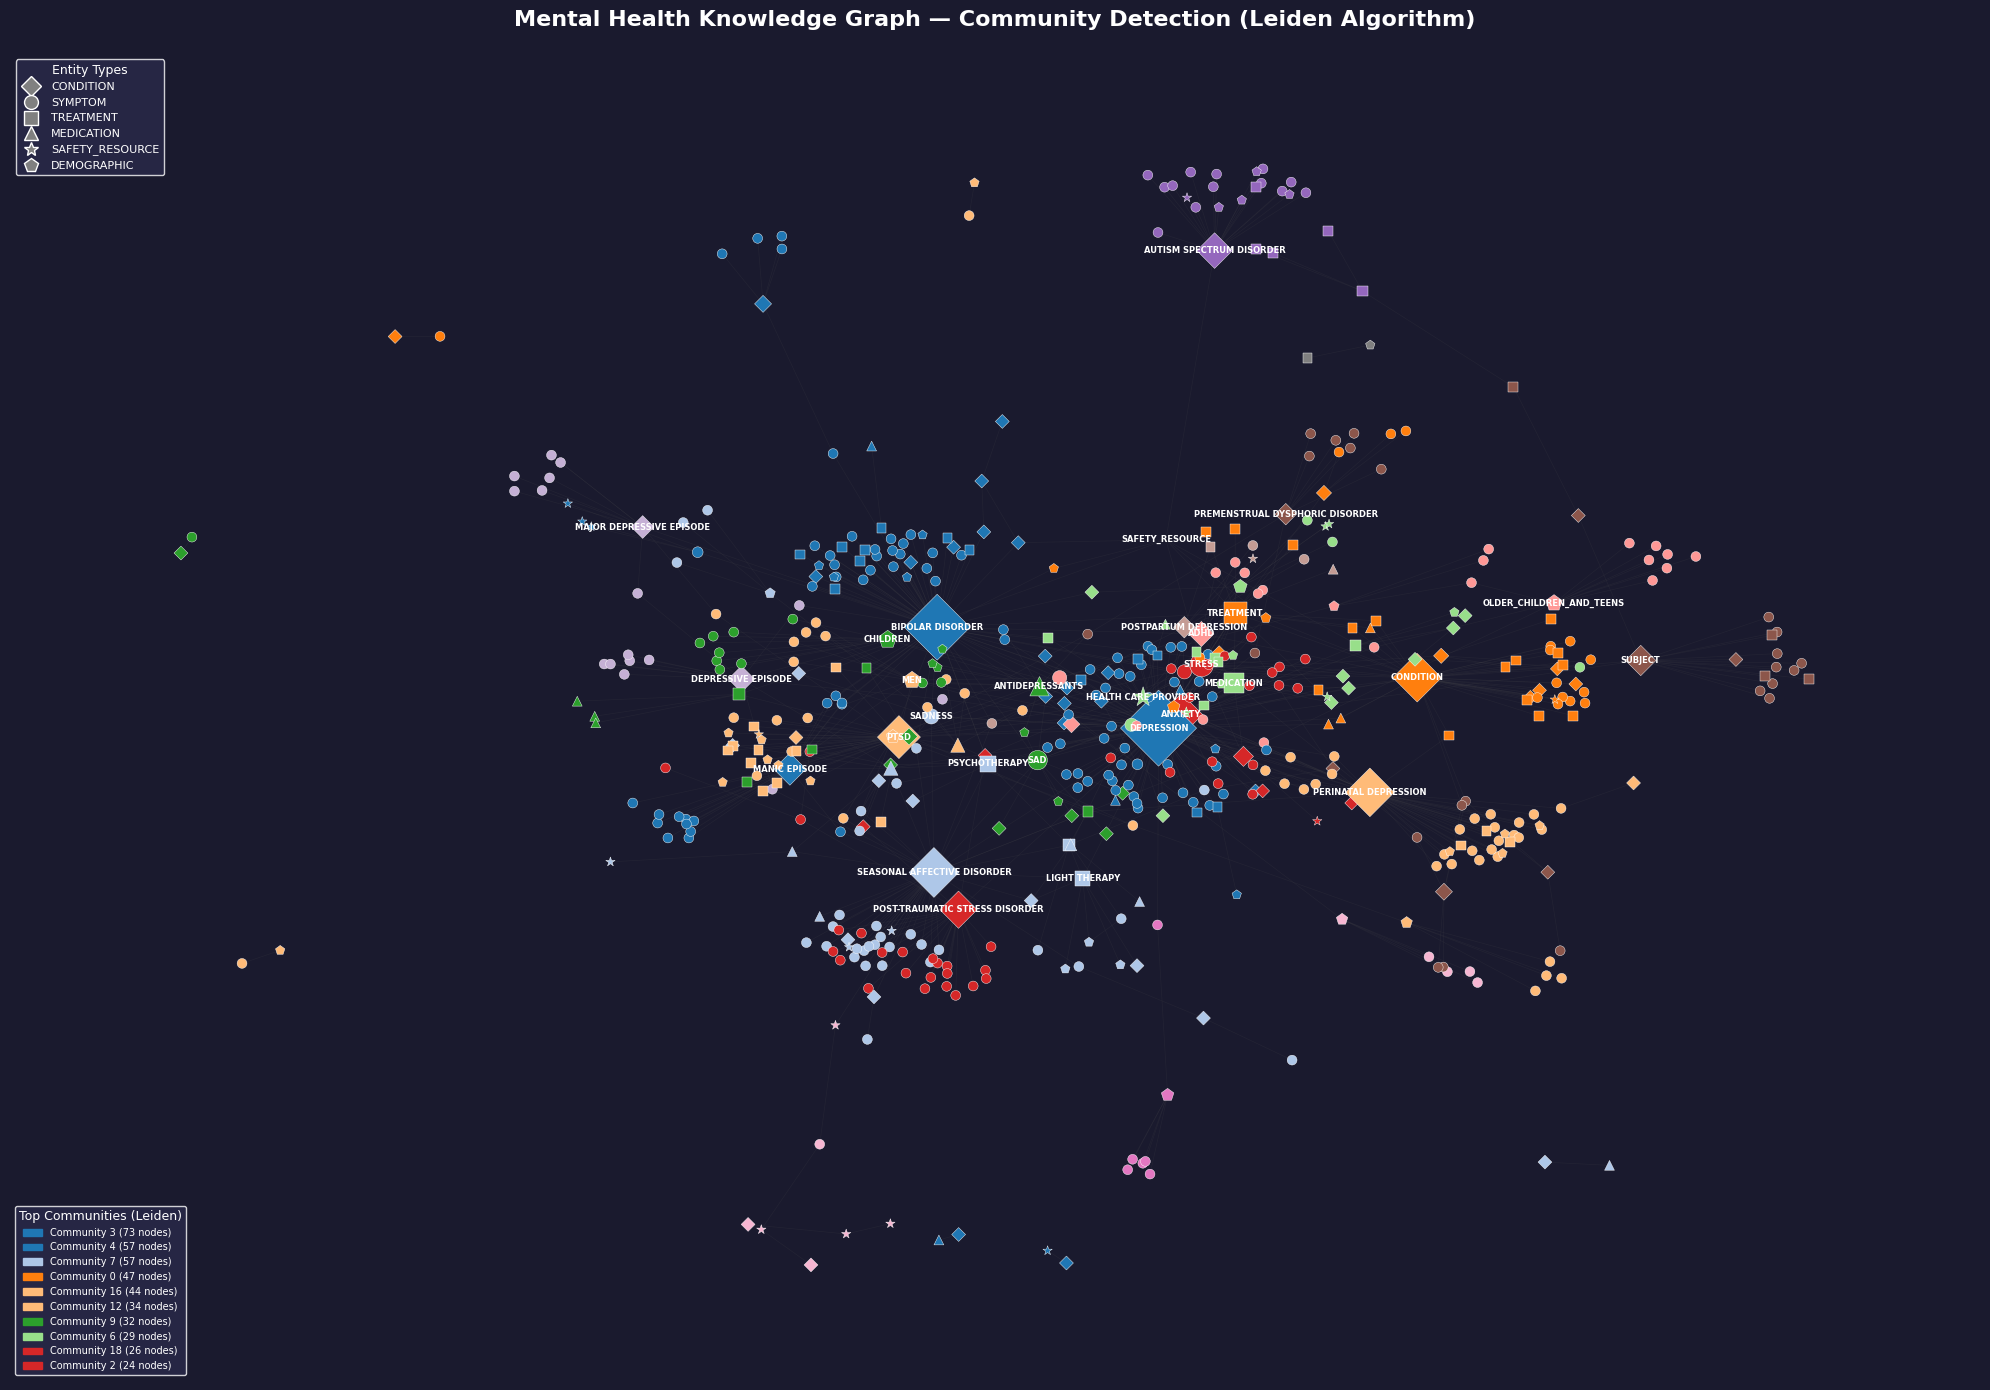


✅ Visualization saved to community_graph_matplotlib.png
   Nodes: 565 | Edges: 718 | Communities: 27


In [26]:
from llama_index.core.graph_stores.types import EntityNode
import networkx as nx
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# COMMUNITY VISUALIZATION WITH MATPLOTLIB + NETWORKX
# ============================================================

# Build the NetworkX graph
G_vis = nx.Graph()

for eid, entity in custom_entities.items():
    G_vis.add_node(eid, name=entity.name, label=entity.label)

for rel in custom_relations:
    if rel.source_id in custom_entities and rel.target_id in custom_entities:
        G_vis.add_edge(rel.source_id, rel.target_id, relation=rel.label)

# Generate distinct colors for each community
random.seed(42)
comm_ids_sorted = sorted(communities.keys(), key=lambda c: -len(communities[c]))
cmap = plt.cm.get_cmap("tab20", max(len(communities), 20))
community_colors_mpl = {}
for idx, comm_id in enumerate(comm_ids_sorted):
    community_colors_mpl[comm_id] = cmap(idx % 20)

# Map node -> community
node_to_comm = {}
for comm_id, member_ids in communities.items():
    for mid in member_ids:
        node_to_comm[mid] = comm_id

# Assign colors & sizes per node
node_colors = []
node_sizes = []
for n in G_vis.nodes():
    comm_id = node_to_comm.get(n, -1)
    node_colors.append(community_colors_mpl.get(comm_id, (0.5, 0.5, 0.5, 1.0)))
    # Size proportional to degree
    node_sizes.append(max(50, G_vis.degree(n) * 15))

# Entity type -> marker (matplotlib doesn't support per-node markers in draw,
# so we'll draw each type separately)
MARKER_MAP = {
    "CONDITION": "D",    # diamond
    "SYMPTOM": "o",      # circle
    "TREATMENT": "s",    # square
    "MEDICATION": "^",   # triangle
    "SAFETY_RESOURCE": "*",  # star
    "DEMOGRAPHIC": "p",  # pentagon
}

# Layout
print("Computing layout (this may take a moment)...")
pos = nx.spring_layout(G_vis, k=0.5, iterations=50, seed=42)

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 14))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

# Draw edges
nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.15, edge_color="#555555", width=0.5)

# Draw nodes grouped by entity type (for different markers)
for entity_type, marker in MARKER_MAP.items():
    type_nodes = [n for n in G_vis.nodes() if custom_entities.get(n, EntityNode(name="", label="")).label == entity_type]
    if not type_nodes:
        continue
    type_colors = [community_colors_mpl.get(node_to_comm.get(n, -1), (0.5, 0.5, 0.5, 1.0)) for n in type_nodes]
    type_sizes = [max(50, G_vis.degree(n) * 15) for n in type_nodes]
    type_pos = {n: pos[n] for n in type_nodes if n in pos}
    
    xs = [type_pos[n][0] for n in type_nodes if n in type_pos]
    ys = [type_pos[n][1] for n in type_nodes if n in type_pos]
    colors_filtered = [c for n, c in zip(type_nodes, type_colors) if n in type_pos]
    sizes_filtered = [s for n, s in zip(type_nodes, type_sizes) if n in type_pos]
    
    ax.scatter(xs, ys, c=colors_filtered, s=sizes_filtered, marker=marker,
               edgecolors="white", linewidths=0.3, zorder=3, label=entity_type)

# Label only high-degree nodes to avoid clutter
degree_threshold = sorted([G_vis.degree(n) for n in G_vis.nodes()], reverse=True)
cutoff = degree_threshold[min(25, len(degree_threshold) - 1)] if degree_threshold else 0
labels = {n: custom_entities[n].name for n in G_vis.nodes()
          if n in custom_entities and G_vis.degree(n) >= cutoff}
nx.draw_networkx_labels(G_vis, pos, labels, font_size=6, font_color="white",
                        font_weight="bold", ax=ax)

# --- Legend: Entity types ---
type_handles = [plt.Line2D([0], [0], marker=m, color='w', markerfacecolor='gray',
                           markersize=10, linestyle='None', label=t)
                for t, m in MARKER_MAP.items()]

# --- Legend: Top communities ---
top_n_legend = min(10, len(comm_ids_sorted))
comm_handles = [mpatches.Patch(color=community_colors_mpl[comm_ids_sorted[i]],
                               label=f"Community {comm_ids_sorted[i]} ({len(communities[comm_ids_sorted[i]])} nodes)")
                for i in range(top_n_legend)]

legend1 = ax.legend(handles=type_handles, loc="upper left", title="Entity Types",
                    fontsize=8, title_fontsize=9, facecolor="#2a2a4a", edgecolor="white",
                    labelcolor="white")
legend1.get_title().set_color("white")
ax.add_artist(legend1)

legend2 = ax.legend(handles=comm_handles, loc="lower left", title="Top Communities (Leiden)",
                    fontsize=7, title_fontsize=9, facecolor="#2a2a4a", edgecolor="white",
                    labelcolor="white")
legend2.get_title().set_color("white")

ax.set_title("Mental Health Knowledge Graph — Community Detection (Leiden Algorithm)",
             fontsize=16, color="white", fontweight="bold", pad=20)
ax.axis("off")

plt.tight_layout()
plt.savefig("community_graph_matplotlib.png", dpi=150, facecolor=fig.get_facecolor(),
            bbox_inches="tight")
plt.show()

print(f"\n✅ Visualization saved to community_graph_matplotlib.png")
print(f"   Nodes: {G_vis.number_of_nodes()} | Edges: {G_vis.number_of_edges()} | Communities: {len(communities)}")

## Load saved summaries

In [38]:
import json

try:
    with open("community_summaries.json") as f:
        community_summaries = json.load(f)
    print(f"✅ Loaded {len(community_summaries)} cached community summaries")
except FileNotFoundError:
    print("⚠️ No cache found — run the summarization block above first")

✅ Loaded 19 cached community summaries


In [41]:
from llama_index.core.graph_stores import SimplePropertyGraphStore
from llama_index.core import PropertyGraphIndex

# ============================================================
# REBUILD INDEX + CREATE LOCAL QUERY ENGINE
# ============================================================

print("--- REBUILDING INDEX ---")

graph_store = SimplePropertyGraphStore()
graph_store.upsert_nodes(list(custom_entities.values()))
graph_store.upsert_relations(custom_relations)

index = PropertyGraphIndex.from_existing(
    property_graph_store=graph_store,
    llm=llm
)

local_query_engine = index.as_query_engine()

print(f"✅ Index rebuilt: {len(custom_entities)} entities, {len(custom_relations)} relations")
print("✅ local_query_engine is ready")

--- REBUILDING INDEX ---
✅ Index rebuilt: 523 entities, 676 relations
✅ local_query_engine is ready


In [48]:
from llama_index.core.llms import ChatMessage

# ============================================================
# STOPWORDS — filtered out before relevance scoring
# ============================================================
STOPWORDS = {
    "what", "are", "the", "of", "is", "a", "an", "how", "why",
    "in", "for", "to", "and", "or", "do", "does", "did", "can",
    "could", "would", "should", "tell", "me", "about", "give",
    "list", "describe", "explain", "i", "my", "your", "their"
}


# ============================================================
# GLOBAL QUERY — community-summary-based search
# ============================================================
def global_query(question, community_summaries, llm, min_score=2, max_communities=8):
    """
    Microsoft GraphRAG Global Search:
    1. Score communities by meaningful keyword overlap (stopwords excluded)
    2. Feed top communities as context to the LLM
    3. Generate a comprehensive answer
    """

    question_lower = question.lower()

    # --- Step 1: Score communities (stopwords excluded) ---
    q_words = set(question_lower.split()) - STOPWORDS

    scored = []
    for comm_id, data in community_summaries.items():
        summary      = data["summary"].lower()
        entities_text = " ".join(data["entities"]).lower()
        combined     = summary + " " + entities_text

        score = sum(1 for w in q_words if w in combined)
        scored.append((comm_id, score, data))

    scored.sort(key=lambda x: -x[1])

    # --- Step 2: Dynamic top_k — communities above min_score threshold ---
    top_communities = [(c, s, d) for c, s, d in scored if s >= min_score][:max_communities]

    # Fallback: if nothing scores high enough, take top 3
    if not top_communities:
        print("  ⚠️ No communities scored above threshold, using top 3 fallback")
        top_communities = scored[:3]

    # --- Step 3: Build context block ---
    context_parts = []
    for comm_id, score, data in top_communities:
        context_parts.append(
            f"[Community {comm_id} | {data['size']} entities | Relevance score: {score}]\n"
            f"{data['summary']}\n"
            f"Key entities: {', '.join(data['entities'][:10])}"
        )

    context = "\n\n---\n\n".join(context_parts)

    # --- Step 4: Generate answer ---
    system_msg = ChatMessage(
        role="system",
        content=(
            "You are a mental health information assistant. Answer the user's question "
            "based STRICTLY on the community summaries provided below. "
            "Do NOT use any outside knowledge or your own training data. "
            "Every single fact in your answer MUST reference a Community by number "
            "(e.g. 'According to Community 4...'). "
            "If a fact cannot be traced to a specific community, do not include it. "
            "If the summaries do not contain enough information, say: "
            "'The available knowledge graph does not contain sufficient information on this topic.'\n\n"
            f"COMMUNITY SUMMARIES:\n{context}"
        )
    )

    user_msg = ChatMessage(role="user", content=question)

    response = llm.chat([system_msg, user_msg]).message.content.strip()
    return response, top_communities


# ============================================================
# HYBRID QUERY — combines local (triplet) + global (community)
# ============================================================
def hybrid_query(question, community_summaries, local_query_engine, llm):
    """
    Runs both local (triplet-level) and global (community-level) search,
    then synthesizes a final answer. Skips local results if they are irrelevant.
    """
    print(f"❓ Question: {question}\n")
    
    
    # ============================================================
    # DOMAIN BOUNDARY CLASSIFIER
    # Rejects out-of-scope questions before they reach the RAG pipeline.
    # No LLM call needed — fast keyword + embedding-free heuristic.
    # ============================================================

    MENTAL_HEALTH_KEYWORDS = {
        # Disorders
        "depression", "anxiety", "ptsd", "trauma", "bipolar", "schizophrenia",
        "ocd", "adhd", "autism", "phobia", "disorder", "syndrome", "psychiatric",
        "mental", "psychological", "mood", "panic", "stress", "grief", "eating",
        # Symptoms
        "symptom", "feeling", "emotion", "suicidal", "hallucination", "delusion",
        "insomnia", "fatigue", "worthlessness", "hopeless", "paranoia",
        # Treatment
        "therapy", "medication", "treatment", "counseling", "psychiatrist",
        "psychologist", "antidepressant", "cbt", "dbt", "emdr", "diagnosis",
        # Crisis
        "suicide", "self-harm", "self harm", "hurt myself", "hurt himself",
        "hurt herself", "end my life", "kill myself", "overdose", "crisis",
    }

    def is_mental_health_query(question: str) -> bool:
        """Returns True if the question is within the mental health domain."""
        q_lower = question.lower()
        return any(kw in q_lower for kw in MENTAL_HEALTH_KEYWORDS)

    OUT_OF_SCOPE_RESPONSE = (
        "I'm a mental health information assistant and can only answer questions "
        "about mental health conditions, symptoms, treatments, and related topics. "
        "For your question, I'd recommend consulting a general-purpose resource. "
        "Is there anything related to mental health I can help you with?"
    )
    
    # ── DOMAIN GUARD ──────────────────────────────────────────
    if not is_mental_health_query(question):
        return {
            "answer":           OUT_OF_SCOPE_RESPONSE,
            "local_result":     "",
            "local_was_useful": False,
            "global_result":    "",
            "communities_used": [],
            "out_of_scope":     True   # flag for the UI later
        }
    # ──────────────────────────────────────────────────────────
    

    # --- Local search ---
    print("🔍 Local Search (triplet-level)...")
    local_response = local_query_engine.query(question)
    local_text     = str(local_response).strip()

    # Check if local result is actually relevant
    
    # FIX — require a MEDICAL keyword match, not just any query word
    # Filter q_words down to only terms that are meaningful entity names
    QUERY_STOPWORDS = {
        "what", "are", "the", "of", "is", "a", "an", "how", "why",
        "in", "for", "to", "and", "or", "do", "does", "did", "can",
        "could", "would", "should", "tell", "me", "about", "give",
        "list", "describe", "explain", "i", "my", "your", "their",
        "symptoms", "treatments", "causes", "effects", "available",  # ← add these
    }

    meaningful_keywords = set(question.lower().split()) - QUERY_STOPWORDS
    local_is_useful = (
        len(meaningful_keywords) > 0 and
        any(kw in local_text.lower() for kw in meaningful_keywords) and
        len(local_text) > 50  # reject empty/trivial responses
    )

    if local_is_useful:
        print(f"  ✅ Local result looks relevant")
    else:
        print(f"  ⚠️ Local result appears irrelevant — will downweight in synthesis")

    # --- Global search ---
    print("🌐 Global Search (community-level)...")
    q_words = set(question.lower().split()) - STOPWORDS
    dynamic_min_score = max(1, len(q_words) // 2)  # e.g. 2 keywords → min_score=1

    global_response, top_comms = global_query(
        question, 
        community_summaries, 
        llm,
        min_score=dynamic_min_score,
        max_communities=8
    )

    communities_used = [(c[0], c[1]) for c in top_comms]
    print(f"  ✅ Used communities: {communities_used}\n")

    # --- Synthesis ---
    if local_is_useful:
        synthesis_instruction = (
            "You are a mental health information assistant. Synthesize the following two "
            "responses into a single, comprehensive answer without repetition.\n\n"
            "The LOCAL response comes from specific knowledge graph triplets.\n"
            "The GLOBAL response comes from community-level summaries.\n\n"
            "When citing facts, prefix them with [LOCAL] or [GLOBAL] so the source is clear.\n\n"
            f"LOCAL SEARCH RESULT:\n{local_text}\n\n"
            f"GLOBAL SEARCH RESULT:\n{global_response}"
        )
    else:
        # Local result is garbage — just polish the global result
        synthesis_instruction = (
            "You are a mental health information assistant. Answer the user's question "
            "based on the following research result. Write a clear, well-structured response.\n\n"
            f"RESEARCH RESULT:\n{global_response}"
        )

    system_msg = ChatMessage(role="system", content=synthesis_instruction)
    user_msg   = ChatMessage(role="user",   content=question)

    final = llm.chat([system_msg, user_msg]).message.content.strip()

    return {
        "answer":           final,
        "local_result":     local_text,
        "local_was_useful": local_is_useful,
        "global_result":    global_response,
        "communities_used": communities_used
    }


# ============================================================
# HELPER — pretty print results
# ============================================================
def print_result(result):
    print("=" * 60)
    print("FINAL ANSWER:")
    print("=" * 60)
    print(result["answer"])
    print()
    print(f"📌 Local result used   : {result['local_was_useful']}")
    print(f"📌 Communities used    : {result['communities_used']}")
    print("=" * 60)


print("✅ Query functions ready: global_query(), hybrid_query(), print_result()")

✅ Query functions ready: global_query(), hybrid_query(), print_result()


In [ ]:
# usage (safe bootstrap for local_query_engine)
from llama_index.core.graph_stores import SimplePropertyGraphStore
from llama_index.core import PropertyGraphIndex

if "local_query_engine" not in globals() or local_query_engine is None:
    print("ℹ️ local_query_engine not found. Building it now...")

    if "index" not in globals() or index is None:
        graph_store = SimplePropertyGraphStore()
        graph_store.upsert_nodes(list(custom_entities.values()))
        graph_store.upsert_relations(custom_relations)
        index = PropertyGraphIndex.from_existing(
            property_graph_store=graph_store,
            llm=llm
        )

    local_query_engine = index.as_query_engine()
    print("✅ local_query_engine initialized")

result = hybrid_query(
    # question = "What are the symptoms of depression?",
    question = "social phobia vs social anxiety disorder",
    community_summaries=community_summaries,
    local_query_engine=local_query_engine,
    llm=llm
)

print_result(result)

❓ Question: social phobia vs social anxiety disorder

🔍 Local Search (triplet-level)...
  ✅ Local result looks relevant
🌐 Global Search (community-level)...
  ✅ Used communities: [('18', 3), ('3', 2), ('7', 2), ('0', 2), ('9', 2), ('14', 2), ('2', 2)]

FINAL ANSWER:
Social phobia and social anxiety disorder refer to the same condition, characterized by an intense fear or anxiety related to social situations [LOCAL]. This condition can lead to significant distress and avoidance of social interactions, impacting daily life and functioning. While the terms are often used interchangeably, they both describe the same underlying issue of fear in social contexts. Unfortunately, there is limited additional information available on this topic [GLOBAL].

📌 Local result used   : True
📌 Communities used    : [('18', 3), ('3', 2), ('7', 2), ('0', 2), ('9', 2), ('14', 2), ('2', 2)]
